In [12]:
from qdmlimits.pdf import show_image

In [13]:
img = show_image("../curves/PhysRevD.107.063001/test.png")

Image size: 2170 × 1242 px  (width × height)


In [14]:
from qdmlimits.calibration import make_calibration
from qdmlimits.calibration import check_calibration

# Read px1, px2 by hovering over two x-axis ticks in the Plotly viewer
# Read py1, py2 by hovering over two y-axis ticks
calib = make_calibration(
  px1=222,  px2=2073,   dx1=1.2,    dx2=10.0,  xlog=True,
  py1=158,   py2=1023,   dy1=1e-39,  dy2=1e-43, ylog=True,
)

check_calibration(img, calib)

In [15]:
from qdmlimits.extraction import pick_color_at, extract_curve_by_color

# 1. Hover over the curve in show_image(img) to read (px, py)
color_bgr = pick_color_at(img, px=1653, py=111)

Sampled at (1653, 111)  RGB=(np.uint8(251), np.uint8(21), np.uint8(29))  BGR=(np.uint8(29), np.uint8(21), np.uint8(251))       


In [16]:
# 2. Extract all pixels of that color
pixels = extract_curve_by_color(img, color_bgr, tol=30)

In [18]:
from qdmlimits.extraction import sort_curve_pixels, smooth_curve, preview_extraction
sorted_pix = sort_curve_pixels(pixels)
sorted_pix = smooth_curve(sorted_pix, window=51, poly=3)

preview_extraction(img, sorted_pix, name="darkside50_NQ")

Saved 1852 points → ../curves/PhysRevD.107.063001/outputs/darkside50_NQ_limit.csv


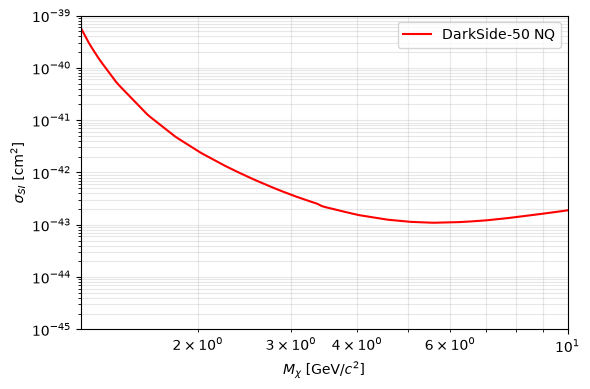

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

x_data, y_data = calib.to_data(sorted_pix[:, 0], sorted_pix[:, 1])

out_path = Path("../curves/PhysRevD.107.063001/outputs/darkside50_NQ_limit.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
np.savetxt(out_path, np.column_stack([x_data, y_data]), delimiter=",", header="x_GeV_per_c2,y_cm2", comments="")
print(f"Saved {len(x_data)} points → {out_path}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_data, y_data, color="red", lw=1.5, label="DarkSide-50 NQ")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.2, 10.0)
ax.set_ylim(1e-45, 1e-39)
ax.set_xlabel(r"$M_\chi\ [\mathrm{GeV}/c^2]$")
ax.set_ylabel(r"$\sigma_{SI}\ [\mathrm{cm}^2]$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()